## Montando DF

In [1]:
import torch
from torchinfo import summary
import pandas as pd
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import numpy as np
import matplotlib.pyplot as plt
import os
import time
from codecarbon import EmissionsTracker
import datetime
import sys
from typing import Union
from scipy.optimize import minimize_scalar

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))
from core.models.encdec_model import EncDecModel
from core.models.stacked_rnn import Stacked_RNN
from domains.previsao_ceu.dataset_module_group import SolarEfficientDatasetGroups
from domains.previsao_ceu.preprocessing import SolarPreprocessor
from core.utils.experiment_manager import ExperimentManager
from core.utils.early_stopping import EarlyStopping
from auxiliary_models.brl_diffuse import BRL
from auxiliary_models.kasten_correction import Kasten_Correction
from core.loss_function.cpiloss import CPILoss
from core.loss_function.mseloss import MaskedMSELoss
from core.loss_function.pyloss import PhysicsGuidedLoss

In [2]:
CONFIG = {
    # --- 1. PATH DA BASE DE DADOS ---
    'csv_path': 'data/pv0.csv',
    
    # --- 2. DIVISÃO DA BASE DE TREINO, TESTE E VALIDAÇÃO ---
    'split_ratios': {'train': 0.8, 'val': 0.2}, 
    'test_year':2022,

    # --- 3. PRÉ-PROCESSAMENTO (Física & Mapeamento) ---
    'preprocessing': {
        'latitude': -23.56,
        'longitude': -46.73,
        'altitude': 0,
        'timezone': 'Etc/GMT+3',
        'nominal_power': 156.0,
        'start_year': 2015,
        'features_to_scale':['temp_amb','wind_speed'],
        #'pv_power_col_csv': 'Pot_BT', # <--- AVALIAR PARA RETIRAR
        
        # DOCUMENTAÇÃO VIVA: Mapeamento "De -> Para"
        # O Preprocessor usará isso para renomear as colunas internamente.
        # Chave (Esquerda): Nome como está no CSV bruto.
        # Valor (Direita): Nome padronizado usado no código.
        'column_mapping': {
            'Pot_BT': 'target',
            'Irradiação Global horária(horizontal) kWh/m2': 'ghi',
            'Irradiação Difusa horária kWh/m2': 'dhi',
            'Irradiação Global horária(Inclinada 27°) kWh/m2': 'irrad_poa',
            'Temperatura ambiente °C': 'temp_amb',
            'Umidade Relativa %': 'humidity',
            'Velocidade média do vento m/s': 'wind_speed'
        }
    },

    # --- 4. ESTRATÉGIA DE MODELAGEM ---
    # mode: 'sky' (prevê k) ou 'power' (prevê kW normalizado)
    'prediction_mode': 'sky',
    
    # Qual variável o modelo vai prever? ('k' ou 'target')
    'target_col': ['kt', 'fracao_difusa'], 
    
    # Features de entrada
    'feature_cols': [
        "kt",'fracao_difusa',
        'cos_zenith', 'elevation', 'delta_kt', 
        'delta_fracao_difusa', 'QS', 
        'temp_amb', 'humidity', 'wind_speed'
    ],
    
    'aux_col':[
        'ghi_cs', 'cos_zenith', 
        'elevation', 'ghi_extra'
    ],

    # --- 5. ARQUITETURA E TREINO ---
    'model_type': 'Teste',
    'cell_type': 'lstm',
    'input_seq_len': 24,
    'output_seq_len': 1,
    'hidden_sizes': [300],
    'learning_rate': 0.001,
    'batch_size': 32,
    'epochs': 10000,
    'dropout': 0.1,
    'bidirectional': False,
    'use_attention': False,
    'use_feature_attention': False,
    'patience': 100,
    'use_mask':True,
    'loss_function':'physics_loss',      # "cpi_loss", "mse", physics_loss
    'physics_base_loss': 'cpi',
    'lambda_hard':1,
    'lambda_soft':1,
}

OUTPUT_ROOT = 'trained_models'
ARTIFACTS_DIR = 'artifacts'
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [3]:
# 1. Setup
timestamp = datetime.datetime.now().strftime("%Y-%m-%d_%H-%M-%S")
exp_name = f"{timestamp}_{CONFIG['model_type']}"
exp_dir = os.path.join(OUTPUT_ROOT, exp_name)
os.makedirs(exp_dir, exist_ok=True)
os.makedirs(ARTIFACTS_DIR, exist_ok=True)

# 2. Leitura
#csv_path = CONFIG['data/pv0.csv']
#print(f"⏳ Lendo: {csv_path}")
df = pd.read_csv('/workspaces/Remodelacao_mestrado/data/pv0.csv')


if 'Date_Time' in df.columns:
    df['Date_Time'] = pd.to_datetime(df['Date_Time'])
    #df['Date_Time'] -=  pd.Timedelta(minutes=30)
    df = df.drop_duplicates(subset=['Date_Time'], keep='first').set_index('Date_Time').sort_index()
df = df[~df.index.duplicated(keep='first')]

# 3. Pré-processamento
pp_conf = CONFIG['preprocessing']

# Instancia passando o mapa explícito. 
# Isso garante que a padronização aconteça conforme o CONFIG acima.
preprocessor = SolarPreprocessor(
    latitude=pp_conf['latitude'], 
    longitude=pp_conf['longitude'], 
    altitude=pp_conf['altitude'],
    timezone=pp_conf['timezone'], 
    nominal_power=pp_conf['nominal_power'], 
    start_year=pp_conf['start_year'],
    cs_model = 'esra',
    features_to_scale=pp_conf['features_to_scale'],
    target_col=CONFIG['prediction_mode'], # <--- unica variavel que não vem do preprocessing
    column_mapping=pp_conf['column_mapping'],
    kasten_corr=True
)

preprocessor.fit(df)
preprocessor.save_scalers(exp_dir)
preprocessor.save_scalers(ARTIFACTS_DIR)

# O método transform usa o column_mapping para renomear as colunas
df_processed = preprocessor.transform(df)

💾 Scalers salvos em: trained_models/2026-03-23_19-25-31_Teste
💾 Scalers salvos em: artifacts
Otimizando TL para 381 dias selecionados...
Otimização concluída. Média TL: 6.28


## Cluster

In [4]:
pip install minisom

Note: you may need to restart the kernel to use updated packages.


### Hora

In [20]:
from minisom import MiniSom

#============================
#   --- Dados Kt, K, VS ---
#      (Quality Control)
#============================

#df_teste_sol = df_processed.loc[(df_processed.index.year < 2022) & (df_processed['mask'] == 1)]
df_teste_gb = df_processed.loc[(df_processed['mask'] == 1)]


data_to_som = df_teste_gb[['kt', 'fracao_difusa',
                            'humidity',
                            'temp_amb']].values

Grade      | QE         | TE         | Min Dias   | Max Dias  
------------------------------------------------------------
2x2        | 0.1613     | 0.0000     | 4571       | 7300      
2x3        | 0.1390     | 0.0000     | 3101       | 5407      
3x3        | 0.1242     | 0.0938     | 1505       | 5069      
3x4        | 0.1146     | 0.1122     | 893        | 4693      
4x4        | 0.1059     | 0.1574     | 555        | 3322      
4x5        | 0.0986     | 0.0830     | 473        | 2259      
5x5        | 0.0938     | 0.1229     | 276        | 1770      
5x6        | 0.0890     | 0.1834     | 189        | 1573      
6x6        | 0.0858     | 0.1867     | 73         | 1486      


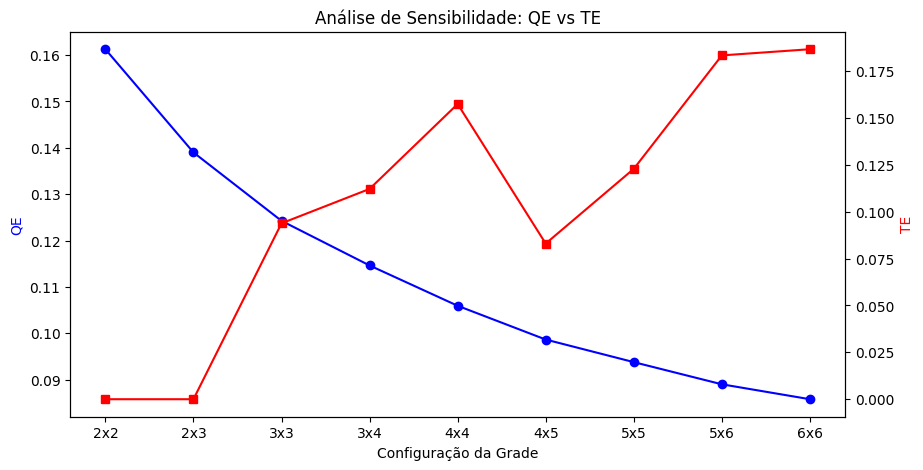

In [21]:
import pandas as pd
import numpy as np
from minisom import MiniSom
import matplotlib.pyplot as plt

# Dimensões para testar
grids = [(2, 2), (2, 3), (3, 3), (3, 4), (4, 4), (4, 5), (5, 5), (5, 6), (6, 6)]
results = []

print(f"{'Grade':<10} | {'QE':<10} | {'TE':<10} | {'Min Dias':<10} | {'Max Dias':<10}")
print("-" * 60)

for x, y in grids:
    # Inicialização e Treino
    som = MiniSom(x, y, data_to_som.shape[1], sigma=1.0, learning_rate=0.5, random_seed=42)
    som.pca_weights_init(data_to_som)
    som.train_random(data_to_som, num_iteration=5000, verbose=False)
    
    # Cálculos
    qe = som.quantization_error(data_to_som)
    te = som.topographic_error(data_to_som)
    
    # Distribuição de Frequência
    winner_coordinates = np.array([som.winner(x) for x in data_to_som])
    cluster_ids = winner_coordinates[:, 0] * y + winner_coordinates[:, 1]
    counts = pd.Series(cluster_ids).value_counts()
    
    results.append({
        'grid': f'{x}x{y}',
        'qe': qe,
        'te': te,
        'counts': counts
    })
    
    print(f"{f'{x}x{y}':<10} | {qe:<10.4f} | {te:<10.4f} | {counts.min():<10} | {counts.max():<10}")

# Plot comparativo de QE e TE
fig, ax1 = plt.subplots(figsize=(10, 5))
nodes = [r['grid'] for r in results]
qes = [r['qe'] for r in results]
tes = [r['te'] for r in results]

ax1.plot(nodes, qes, 'b-o', label='Quantization Error (QE)')
ax1.set_xlabel('Configuração da Grade')
ax1.set_ylabel('QE', color='b')

ax2 = ax1.twinx()
ax2.plot(nodes, tes, 'r-s', label='Topographic Error (TE)')
ax2.set_ylabel('TE', color='r')

plt.title('Análise de Sensibilidade: QE vs TE')
plt.show()

 [ 5000 / 5000 ] 100% - 0:00:00 left 
 quantization error: 0.13569113352179035
                           target    ghi  irrad_poa  temp_amb  humidity  \
Date_Time                                                                 
2015-06-13 09:00:00-03:00     0.0  274.0      390.0  0.692282    0.6727   
2015-06-13 10:00:00-03:00     0.0  437.0      601.0  0.712849    0.5633   
2015-06-13 11:00:00-03:00     0.0  553.0      763.0  0.737936    0.4946   
2015-06-13 12:00:00-03:00     0.0  618.0      863.0  0.752514    0.4684   
2015-06-13 13:00:00-03:00     0.0  620.0      887.0  0.764493    0.3869   

                           wind_speed  Pressão Baromêtrica mm Hg  \
Date_Time                                                          
2015-06-13 09:00:00-03:00    0.227401                      438.7   
2015-06-13 10:00:00-03:00    0.410075                      438.7   
2015-06-13 11:00:00-03:00    0.622881                      438.7   
2015-06-13 12:00:00-03:00    0.608286                  

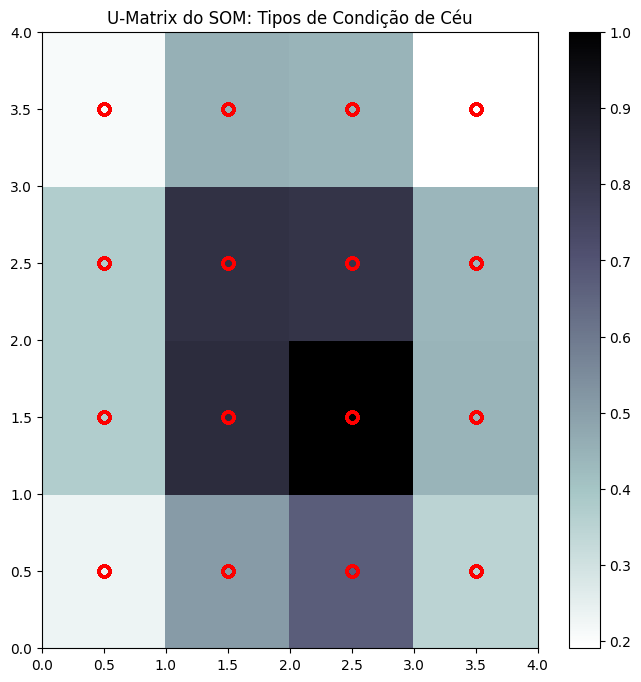

In [9]:
# Configurações do SOM
som_grid_x = 4
som_grid_y = 4
input_len = data_to_som.shape[1] # Deve ser 6

som = MiniSom(som_grid_x, som_grid_y, input_len, sigma=1.0, learning_rate=0.5)

# Inicialização dos pesos e treinamento
som.pca_weights_init(data_to_som)
som.train_random(data_to_som, num_iteration=5000, verbose=True)

# Função para mapear cada dia para um ID de cluster
def get_cluster_id(sample):
    w = som.winner(sample)
    return w[0] * som_grid_y + w[1]

# Criando a coluna de grupo
df_teste_gb['cluster_id'] = [get_cluster_id(x) for x in data_to_som]

print(df_teste_gb.head())

plt.figure(figsize=(8, 8))
plt.pcolor(som.distance_map().T, cmap='bone_r')  # Plot da distância entre neurônios
plt.colorbar()

# Adicionando marcadores para os dias
for i, x in enumerate(data_to_som):
    w = som.winner(x)
    plt.plot(w[0] + 0.5, w[1] + 0.5, 'o', markerfacecolor='None', 
             markeredgecolor='r', markersize=8, markeredgewidth=2)

plt.title('U-Matrix do SOM: Tipos de Condição de Céu')
plt.show()

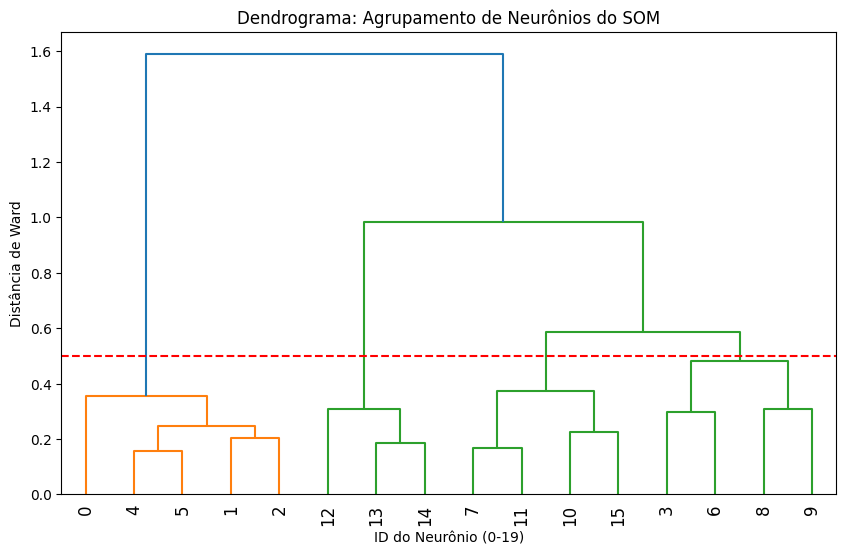

super_cluster
2    8185
0    8012
4    3011
5    2114
3    1970
1    1619
Name: count, dtype: int64


In [10]:
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import AgglomerativeClustering

# 1. Extrair os pesos (codebook vectors) do SOM 4x5
# weights terá formato (20, n_features)
weights = som.get_weights().reshape(-1, data_to_som.shape[1])

# 2. Gerar a Linkage Matrix (usando o método de Ward para minimizar a variância)
Z = linkage(weights, method='ward')

# 3. Plotar o Dendrograma para decisão do "corte"
plt.figure(figsize=(10, 6))
dendrogram(Z, leaf_rotation=90., leaf_font_size=12.)
plt.title('Dendrograma: Agrupamento de Neurônios do SOM')
plt.xlabel('ID do Neurônio (0-19)')
plt.ylabel('Distância de Ward')
plt.axhline(y=0.5, color='r', linestyle='--') # Linha hipotética de corte
plt.show()

# 4. Executar o agrupamento final (exemplo: reduzindo para 5 Super-Clusters)
n_super_clusters = 6
hac = AgglomerativeClustering(n_clusters=n_super_clusters, linkage='ward')
super_labels = hac.fit_predict(weights)

# 5. Mapear os dias originais para os novos Super-Clusters
# Criamos um dicionário: ID_Neurônio -> ID_SuperCluster
mapping_dict = {i: label for i, label in enumerate(super_labels)}

# No seu dataframe original (daily_features), criamos a nova coluna
df_teste_gb['super_cluster'] = df_teste_gb['cluster_id'].map(mapping_dict)

print(df_teste_gb['super_cluster'].value_counts())

In [16]:
df_teste_gb

,target,ghi,irrad_poa,temp_amb,humidity,wind_speed,Pressão Baromêtrica mm Hg,Pluviômetro mm,zenith,apparent_zenith,...,P_fracao_difusa,P_kt,P1,P2,P3,irr_clearsky_ratio,delta_kt,delta_fracao_difusa,cluster_id,super_cluster
Date_Time,,,,,,,,,,,,,,,,,,,,,
2015-06-13 09:00:00-03:00,0.000000,274.0,390.0,0.692282,0.6727,0.227401,438.70,0.0,65.165910,65.129885,...,0.375669,0.250215,0.002867,0.000578,0.000000,1.423358,0.242756,-0.202889,5,0
2015-06-13 10:00:00-03:00,0.000000,437.0,601.0,0.712849,0.5633,0.410075,438.70,0.0,56.010627,55.985757,...,0.172781,0.492971,0.005198,0.002867,0.000578,1.375286,0.097708,-0.040806,5,0
2015-06-13 11:00:00-03:00,0.000000,553.0,763.0,0.737936,0.4946,0.622881,438.70,0.0,49.513987,49.494306,...,0.131975,0.590679,0.005951,0.005198,0.002867,1.379747,0.052923,-0.015278,4,0
2015-06-13 12:00:00-03:00,0.000000,618.0,863.0,0.752514,0.4684,0.608286,438.70,0.0,46.802537,46.784635,...,0.116697,0.643602,0.006316,0.005951,0.005198,1.396440,0.038608,-0.008896,4,0
2015-06-13 13:00:00-03:00,0.000000,620.0,887.0,0.764493,0.3869,0.592750,438.70,0.0,48.517199,48.498194,...,0.107801,0.682210,0.006410,0.006316,0.005951,1.430645,0.025063,0.004710,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2022-12-31 14:00:00-03:00,0.134928,444.0,397.0,0.741553,0.7930,0.024482,700.28,0.1,25.228617,25.220691,...,0.602813,0.526861,0.004856,0.003620,0.005883,0.894144,-0.179734,0.128371,15,3
2022-12-31 15:00:00-03:00,0.053168,101.0,93.0,0.704712,0.8590,0.043315,700.43,5.7,38.890788,38.877216,...,0.731183,0.347127,0.003295,0.004856,0.003620,0.920792,-0.255353,0.232807,12,2
2022-12-31 16:00:00-03:00,0.148698,165.0,161.0,0.690813,0.9500,0.023540,699.99,4.6,52.430818,52.408993,...,0.963990,0.091774,0.000918,0.003295,0.004856,0.975758,0.099618,0.002515,12,2


<Axes: xlabel='kt', ylabel='fracao_difusa'>

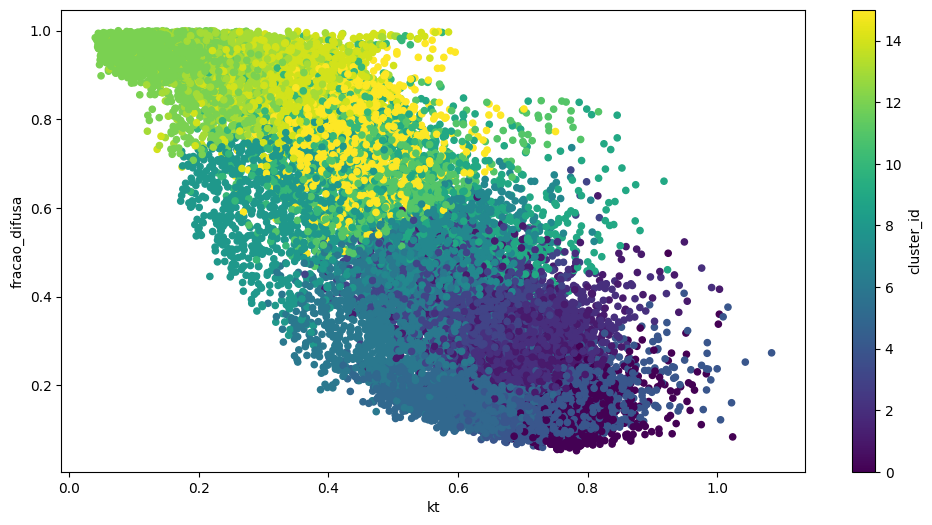

In [17]:
df_teste_gb.plot.scatter(x='kt',
                      y='fracao_difusa',
                      c = 'cluster_id',
                      colormap = 'viridis',
                      figsize = (12,6))

### Dia

In [5]:
from minisom import MiniSom

#============================
#   --- Dados Kt, K, VS ---
#      (Quality Control)
#============================

#df_teste_sol = df_processed.loc[(df_processed.index.year < 2022) & (df_processed['mask'] == 1)]
df_teste_sol = df_processed.loc[(df_processed['mask'] == 1)]

df_teste_sol_gb = df_teste_sol.groupby(df_teste_sol.index.date).agg({
    'kt': ['mean', 'var'],
    'fracao_difusa': ['mean', 'var'],
    'VS_cdfn':['mean', 'var']
})
df_teste_sol_gb.columns = ['kt_mean', 'kt_var', 
                           'kd_mean', 'kd_var', 
                           'VS_mean', 'VS_var']

df_teste_sol_gb = df_teste_sol_gb.dropna() # Remover dias com falhas

#===========================
#   --- Dados Meteo ---
#===========================

#df_teste_meteo = df_processed.loc[(df_processed.index.year < 2022)]
df_teste_meteo = df_processed.copy()

df_teste_meteo_gb = df_teste_meteo.groupby(df_teste_meteo.index.date).agg({
    'humidity':['mean', 'var'],
    'temp_amb': [lambda x: x.max() - x.min()],
    #'aod550':['mean']
})

df_teste_meteo_gb.columns = ['rh_mean', 'rh_var', 
                             'ta_amplitude', 
                             #'aod_mean'
                             ]

df_teste_meteo_gb = df_teste_meteo_gb.dropna()

#=============================
#   --- Junção dos Dados ---
#=============================
df_teste_gb = pd.merge(df_teste_sol_gb, df_teste_meteo_gb, 
                        right_index=True, 
                        left_index=True,
                        how='inner')

data_to_som = df_teste_gb.values

Grade      | QE         | TE         | Min Dias   | Max Dias  
------------------------------------------------------------
2x2        | 0.1281     | 0.0000     | 547        | 749       
2x3        | 0.1101     | 0.0000     | 336        | 542       
3x3        | 0.0999     | 0.2243     | 166        | 355       
3x4        | 0.0938     | 0.1738     | 23         | 336       
4x4        | 0.0879     | 0.2158     | 4          | 304       
4x5        | 0.0839     | 0.1857     | 12         | 259       
5x5        | 0.0793     | 0.2135     | 4          | 217       
5x6        | 0.0766     | 0.2081     | 4          | 207       
6x6        | 0.0729     | 0.2412     | 4          | 139       


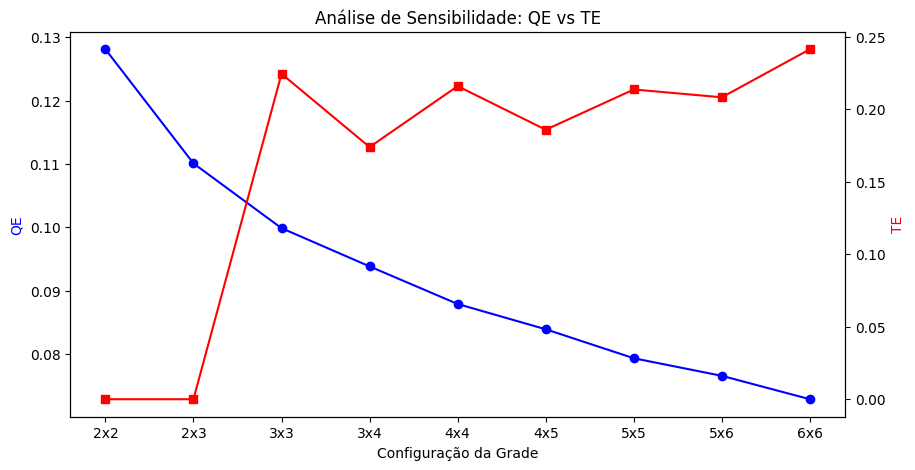

In [6]:
import pandas as pd
import numpy as np
from minisom import MiniSom
import matplotlib.pyplot as plt

# Dimensões para testar
grids = [(2, 2), (2, 3), (3, 3), (3, 4), (4, 4), (4, 5), (5, 5), (5, 6), (6, 6)]
results = []

print(f"{'Grade':<10} | {'QE':<10} | {'TE':<10} | {'Min Dias':<10} | {'Max Dias':<10}")
print("-" * 60)

for x, y in grids:
    # Inicialização e Treino
    som = MiniSom(x, y, data_to_som.shape[1], sigma=1.0, learning_rate=0.5, random_seed=42)
    som.pca_weights_init(data_to_som)
    som.train_random(data_to_som, num_iteration=5000, verbose=False)
    
    # Cálculos
    qe = som.quantization_error(data_to_som)
    te = som.topographic_error(data_to_som)
    
    # Distribuição de Frequência
    winner_coordinates = np.array([som.winner(x) for x in data_to_som])
    cluster_ids = winner_coordinates[:, 0] * y + winner_coordinates[:, 1]
    counts = pd.Series(cluster_ids).value_counts()
    
    results.append({
        'grid': f'{x}x{y}',
        'qe': qe,
        'te': te,
        'counts': counts
    })
    
    print(f"{f'{x}x{y}':<10} | {qe:<10.4f} | {te:<10.4f} | {counts.min():<10} | {counts.max():<10}")

# Plot comparativo de QE e TE
fig, ax1 = plt.subplots(figsize=(10, 5))
nodes = [r['grid'] for r in results]
qes = [r['qe'] for r in results]
tes = [r['te'] for r in results]

ax1.plot(nodes, qes, 'b-o', label='Quantization Error (QE)')
ax1.set_xlabel('Configuração da Grade')
ax1.set_ylabel('QE', color='b')

ax2 = ax1.twinx()
ax2.plot(nodes, tes, 'r-s', label='Topographic Error (TE)')
ax2.set_ylabel('TE', color='r')

plt.title('Análise de Sensibilidade: QE vs TE')
plt.show()

 [ 5000 / 5000 ] 100% - 0:00:00 left 
 quantization error: 0.11205640628434126
             kt_mean    kt_var   kd_mean    kd_var   VS_mean    VS_var  \
2015-06-13  0.685277  0.012047  0.142296  0.000842  0.070659  0.000850   
2015-06-14  0.605509  0.010481  0.224970  0.035110  0.107754  0.001706   
2015-06-16  0.379081  0.013876  0.837211  0.007547  0.225967  0.011936   
2015-06-17  0.439925  0.015305  0.874979  0.012392  0.227742  0.007688   
2015-06-18  0.561303  0.016125  0.380346  0.076054  0.176102  0.006230   

             rh_mean    rh_var  ta_amplitude  cluster_id  
2015-06-13  0.686892  0.044254      0.148943           0  
2015-06-14  0.624721  0.022335      0.136739           0  
2015-06-16  0.812913  0.007374      0.066222           5  
2015-06-17  0.788754  0.016348      0.113233           5  
2015-06-18  0.785942  0.029244      0.135609           3  


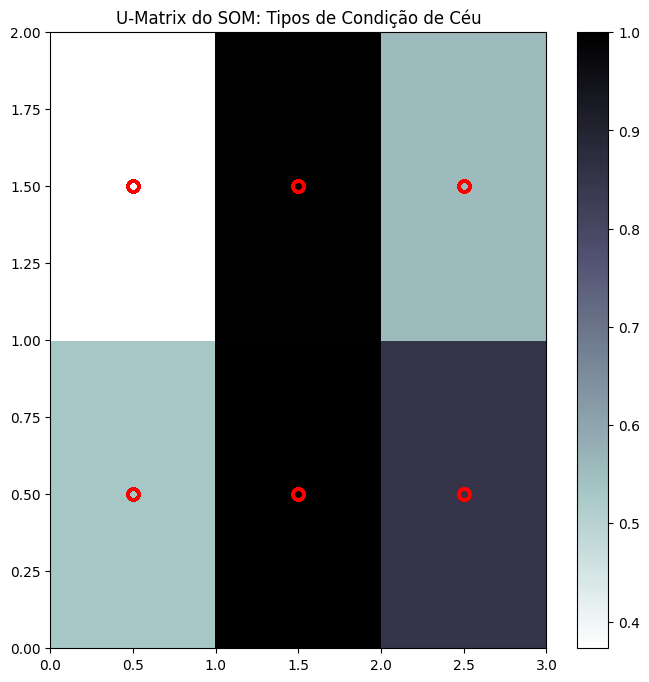

In [7]:
# Configurações do SOM
som_grid_x = 3
som_grid_y = 2
input_len = data_to_som.shape[1] # Deve ser 6

som = MiniSom(som_grid_x, som_grid_y, input_len, sigma=1.0, learning_rate=0.5)

# Inicialização dos pesos e treinamento
som.pca_weights_init(data_to_som)
som.train_random(data_to_som, num_iteration=5000, verbose=True)

# Função para mapear cada dia para um ID de cluster
def get_cluster_id(sample):
    w = som.winner(sample)
    return w[0] * som_grid_y + w[1]

# Criando a coluna de grupo
df_teste_gb['cluster_id'] = [get_cluster_id(x) for x in data_to_som]

print(df_teste_gb.head())

plt.figure(figsize=(8, 8))
plt.pcolor(som.distance_map().T, cmap='bone_r')  # Plot da distância entre neurônios
plt.colorbar()

# Adicionando marcadores para os dias
for i, x in enumerate(data_to_som):
    w = som.winner(x)
    plt.plot(w[0] + 0.5, w[1] + 0.5, 'o', markerfacecolor='None', 
             markeredgecolor='r', markersize=8, markeredgewidth=2)

plt.title('U-Matrix do SOM: Tipos de Condição de Céu')
plt.show()

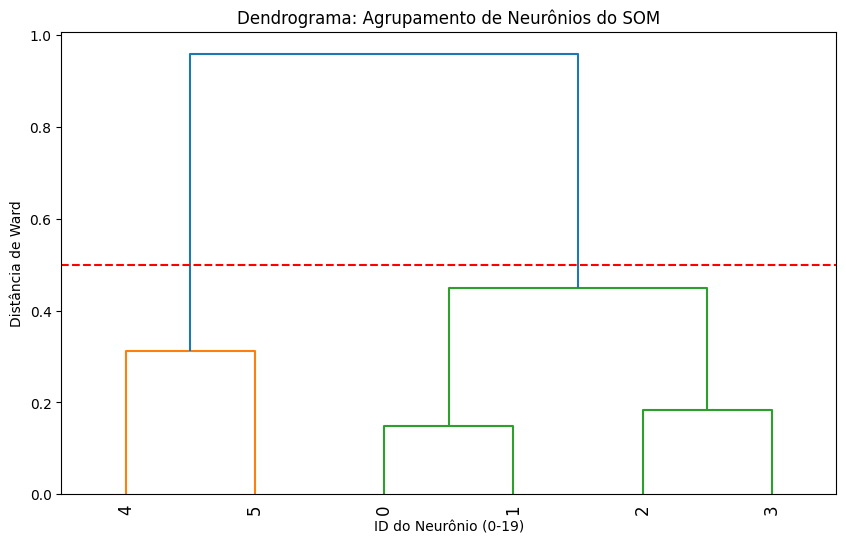

super_cluster
1    481
4    473
0    470
2    439
5    370
3    362
Name: count, dtype: int64


In [8]:
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import AgglomerativeClustering

# 1. Extrair os pesos (codebook vectors) do SOM 4x5
# weights terá formato (20, n_features)
weights = som.get_weights().reshape(-1, data_to_som.shape[1])

# 2. Gerar a Linkage Matrix (usando o método de Ward para minimizar a variância)
Z = linkage(weights, method='ward')

# 3. Plotar o Dendrograma para decisão do "corte"
plt.figure(figsize=(10, 6))
dendrogram(Z, leaf_rotation=90., leaf_font_size=12.)
plt.title('Dendrograma: Agrupamento de Neurônios do SOM')
plt.xlabel('ID do Neurônio (0-19)')
plt.ylabel('Distância de Ward')
plt.axhline(y=0.5, color='r', linestyle='--') # Linha hipotética de corte
plt.show()

# 4. Executar o agrupamento final (exemplo: reduzindo para 5 Super-Clusters)
n_super_clusters = 6
hac = AgglomerativeClustering(n_clusters=n_super_clusters, linkage='ward')
super_labels = hac.fit_predict(weights)

# 5. Mapear os dias originais para os novos Super-Clusters
# Criamos um dicionário: ID_Neurônio -> ID_SuperCluster
mapping_dict = {i: label for i, label in enumerate(super_labels)}

# No seu dataframe original (daily_features), criamos a nova coluna
df_teste_gb['super_cluster'] = df_teste_gb['cluster_id'].map(mapping_dict)

print(df_teste_gb['super_cluster'].value_counts())

In [9]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Associar os clusters ao dataframe de dados horários
# Certifique-se que o índice de 'df_horario' coincide com o de 'daily_features'
df_teste = df_processed.copy()
df_teste['data_only'] = df_teste.index.date

# 3. Fazemos o merge para trazer o cluster_id para cada hora
df_teste = pd.merge(df_teste, df_teste_gb[['cluster_id', 'super_cluster']], 
                              left_on='data_only', 
                              right_index=True, 
                              how='inner')

df_teste[['cluster_id', 'super_cluster']].head()

,cluster_id,super_cluster
Date_Time,,
2015-06-13 00:00:00-03:00,0,5
2015-06-13 01:00:00-03:00,0,5
2015-06-13 02:00:00-03:00,0,5
2015-06-13 03:00:00-03:00,0,5
2015-06-13 04:00:00-03:00,0,5


<Axes: xlabel='kt_mean', ylabel='kd_mean'>

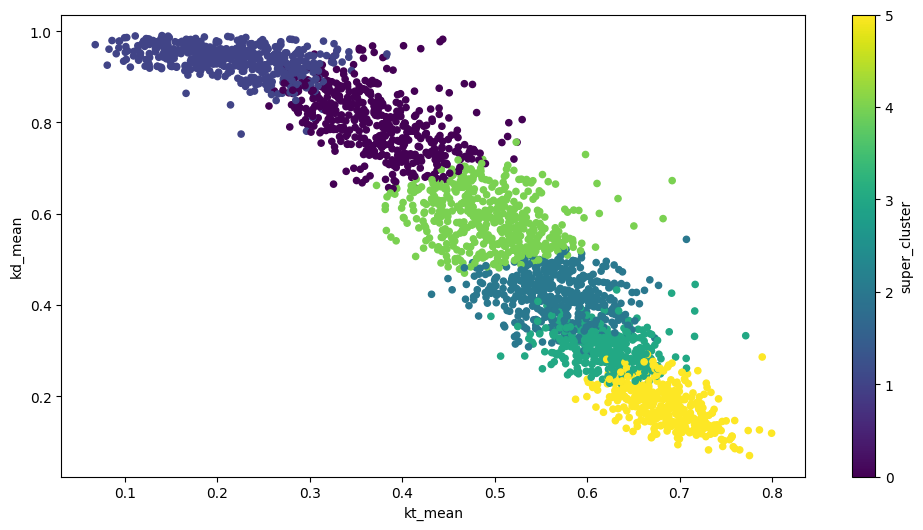

In [10]:
df_teste_gb.plot.scatter(x='kt_mean',
                      y='kd_mean',
                      c = 'super_cluster',
                      colormap = 'viridis',
                      figsize = (12,6))

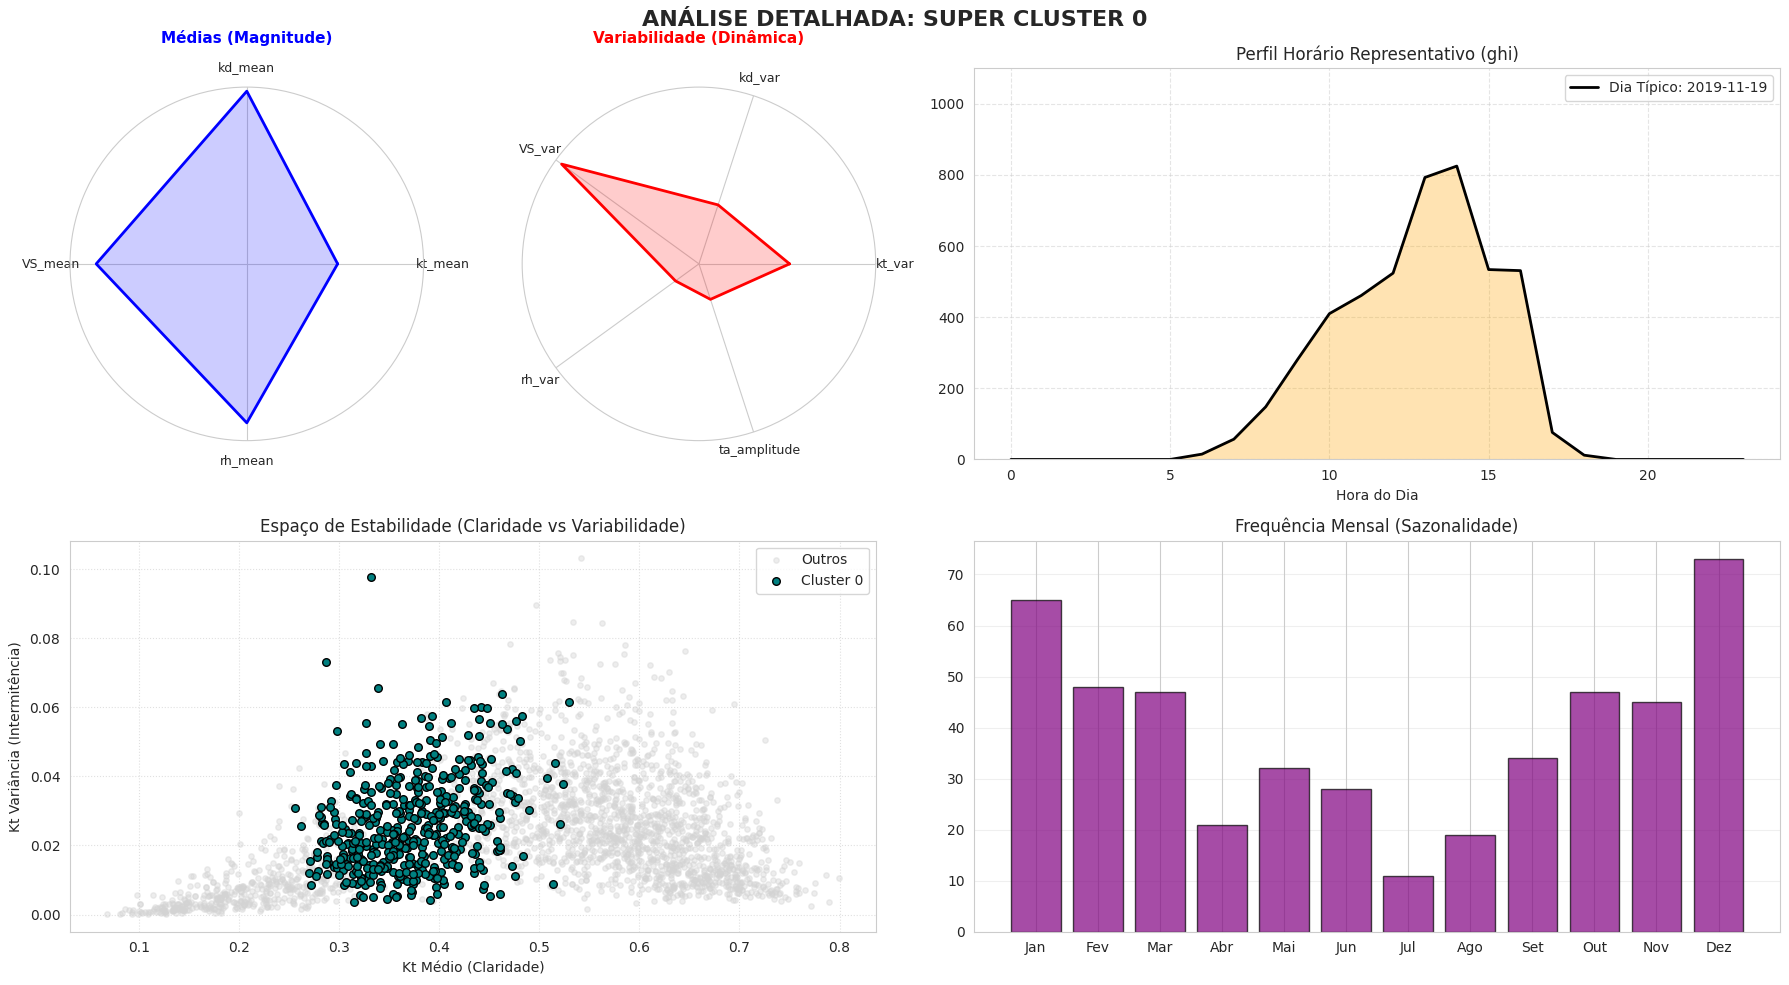

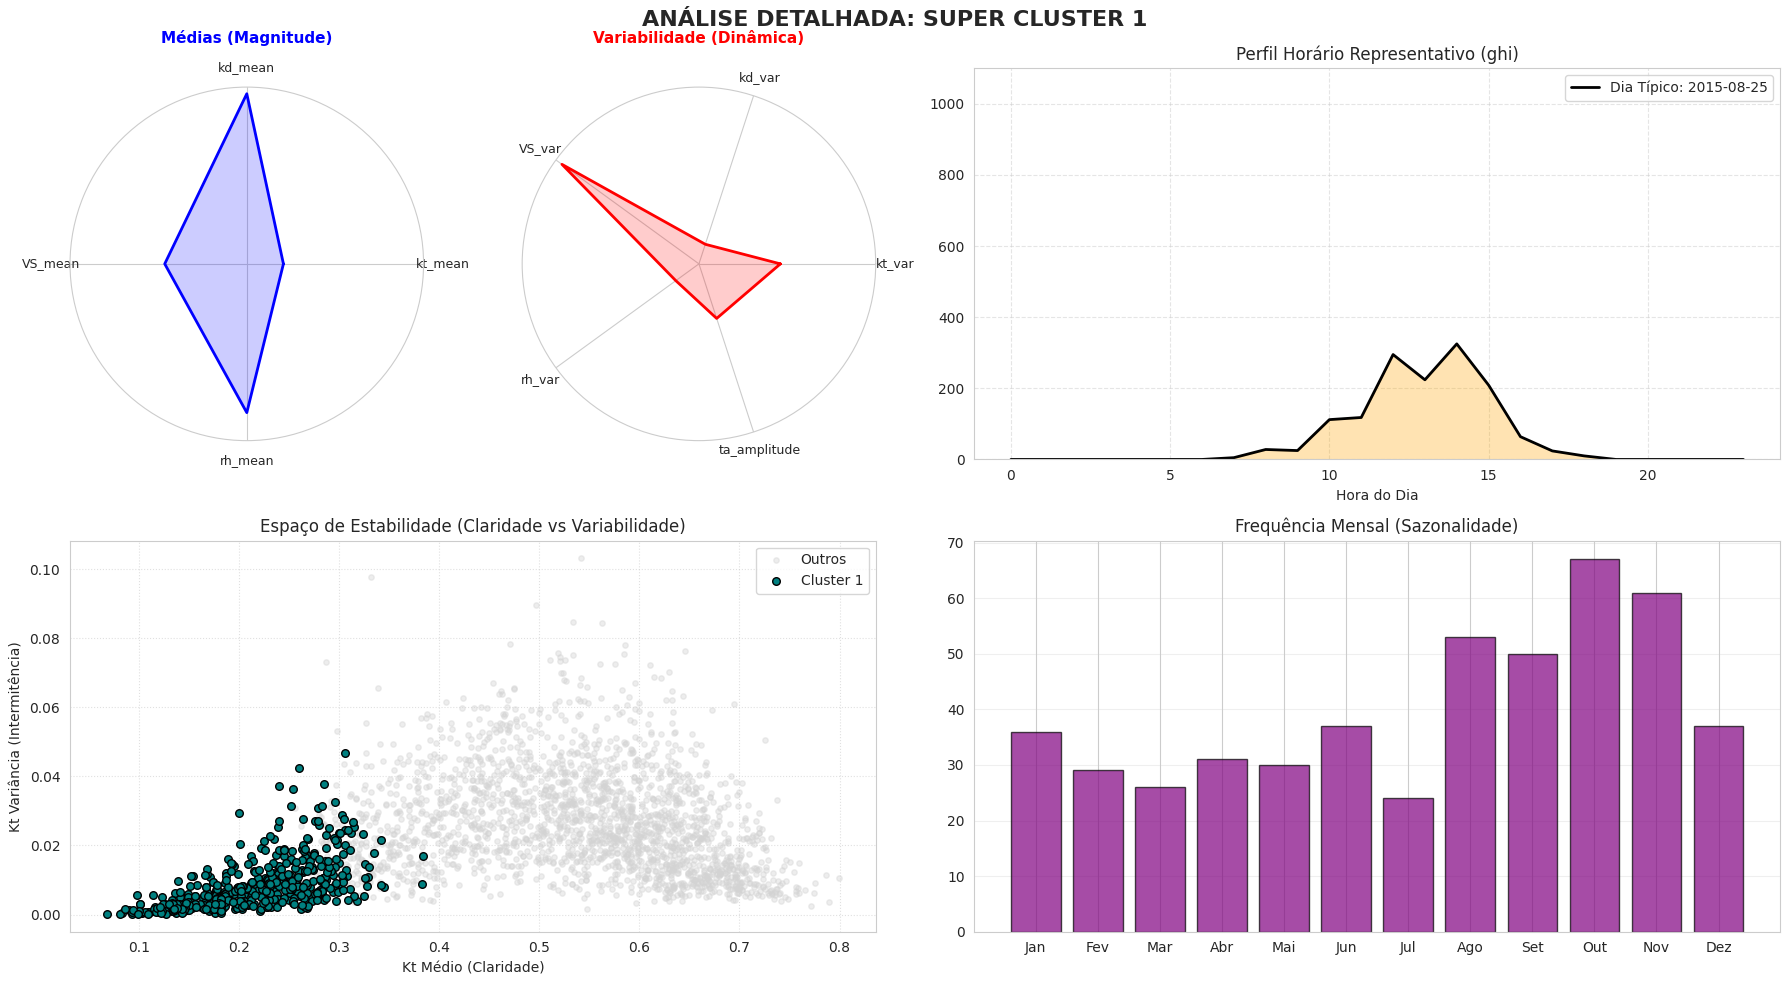

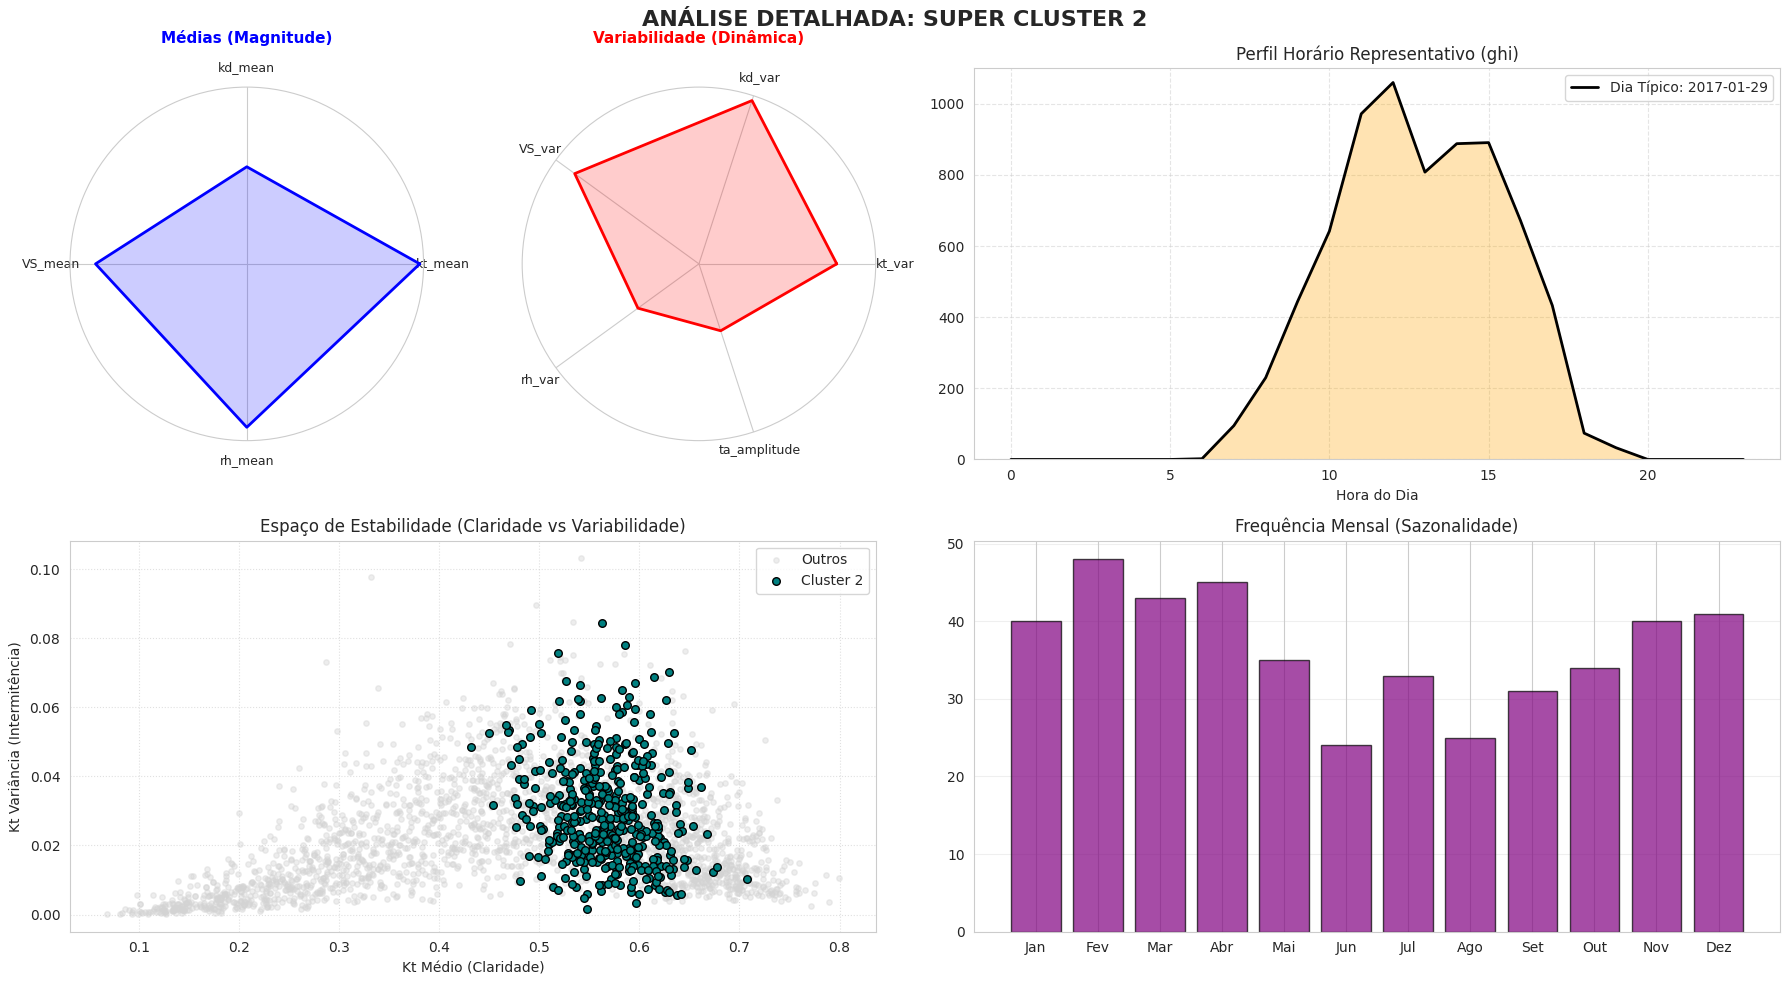

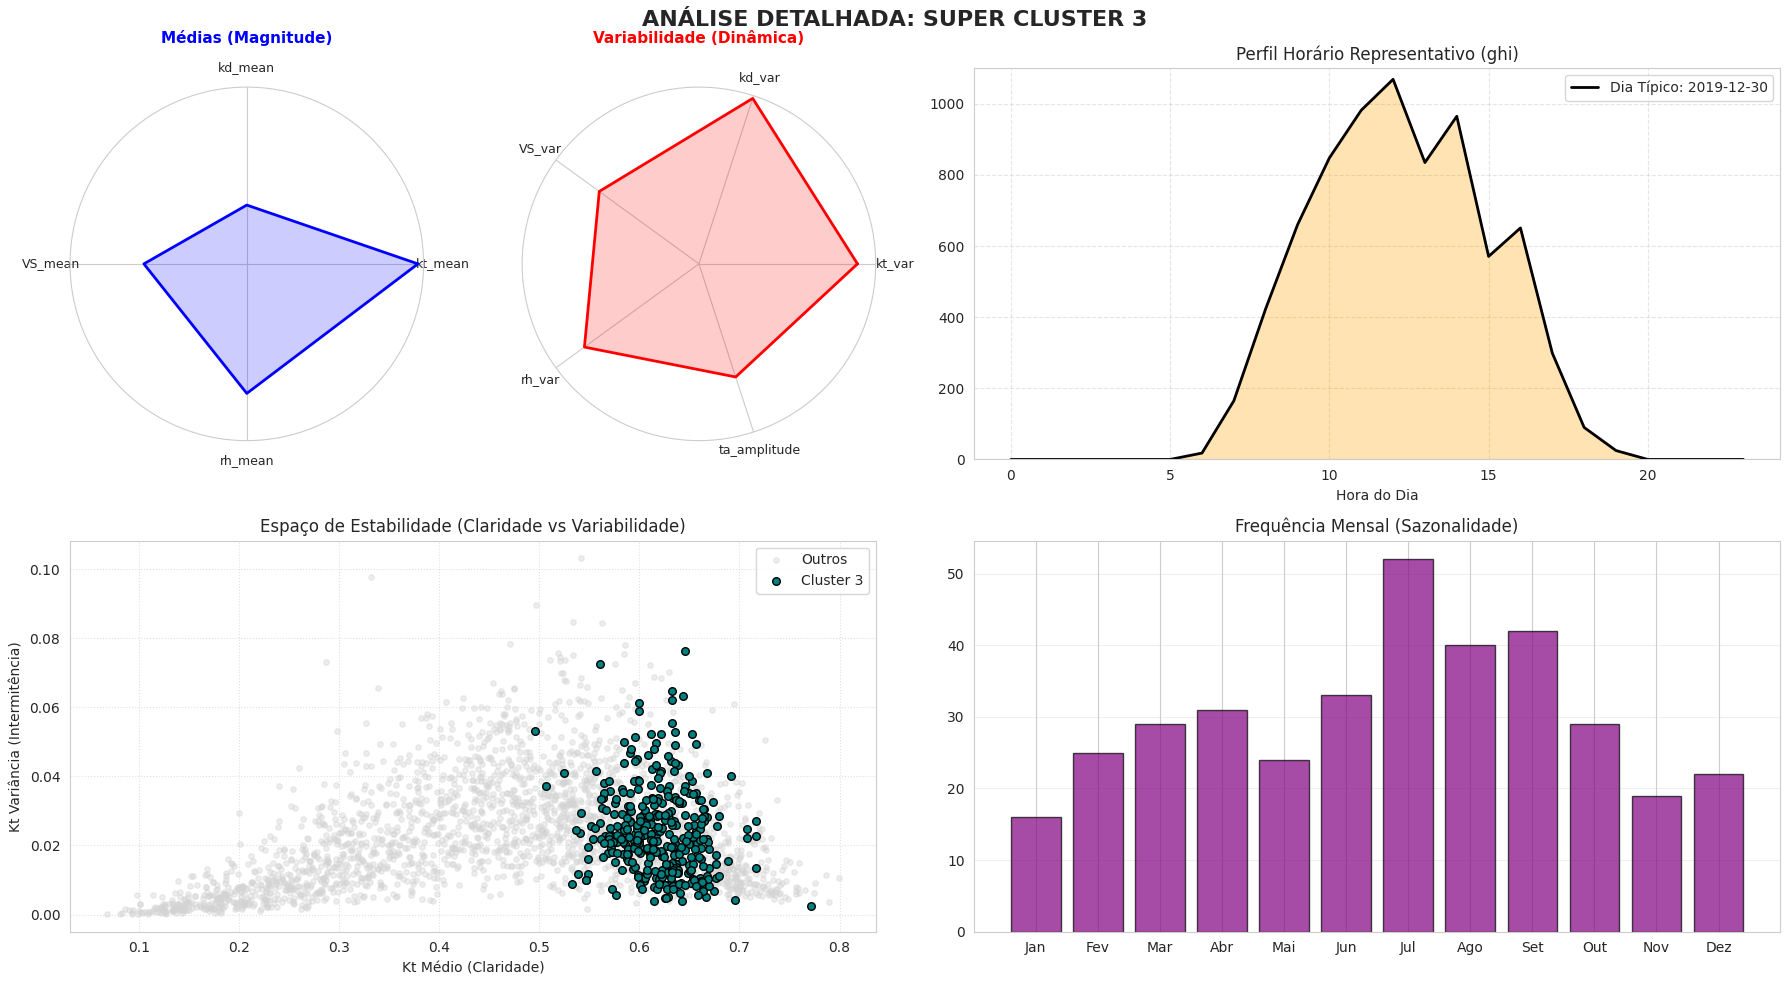

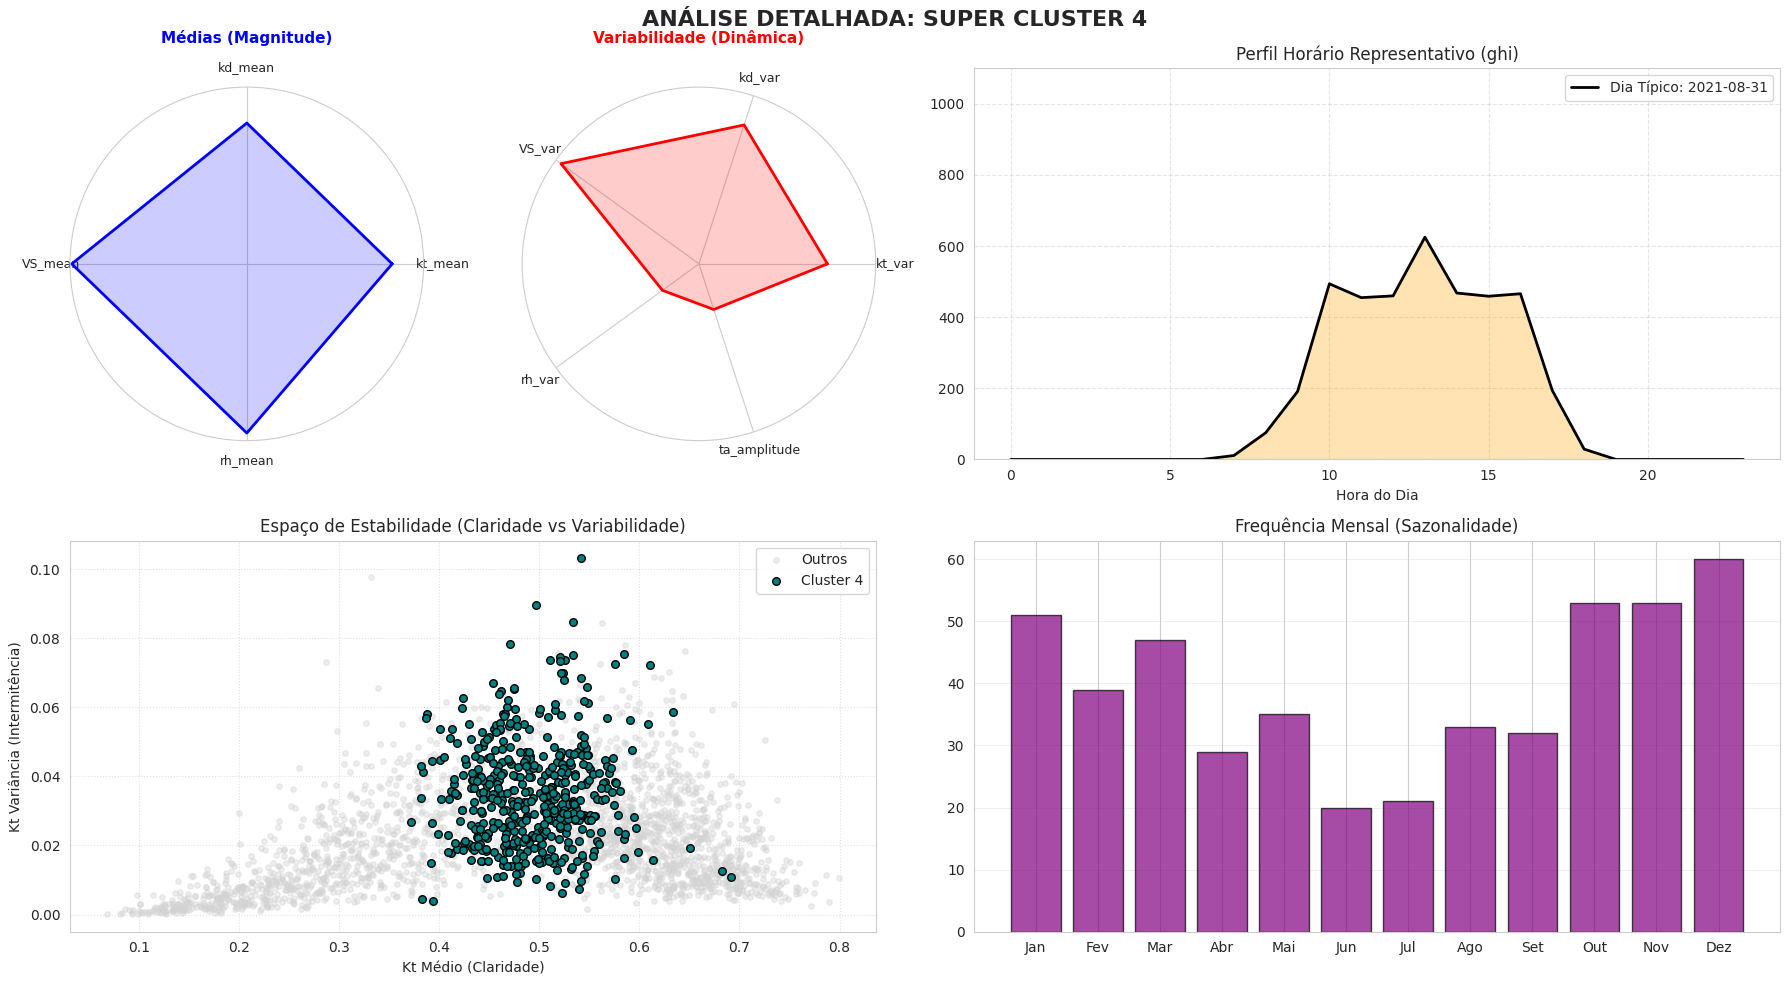

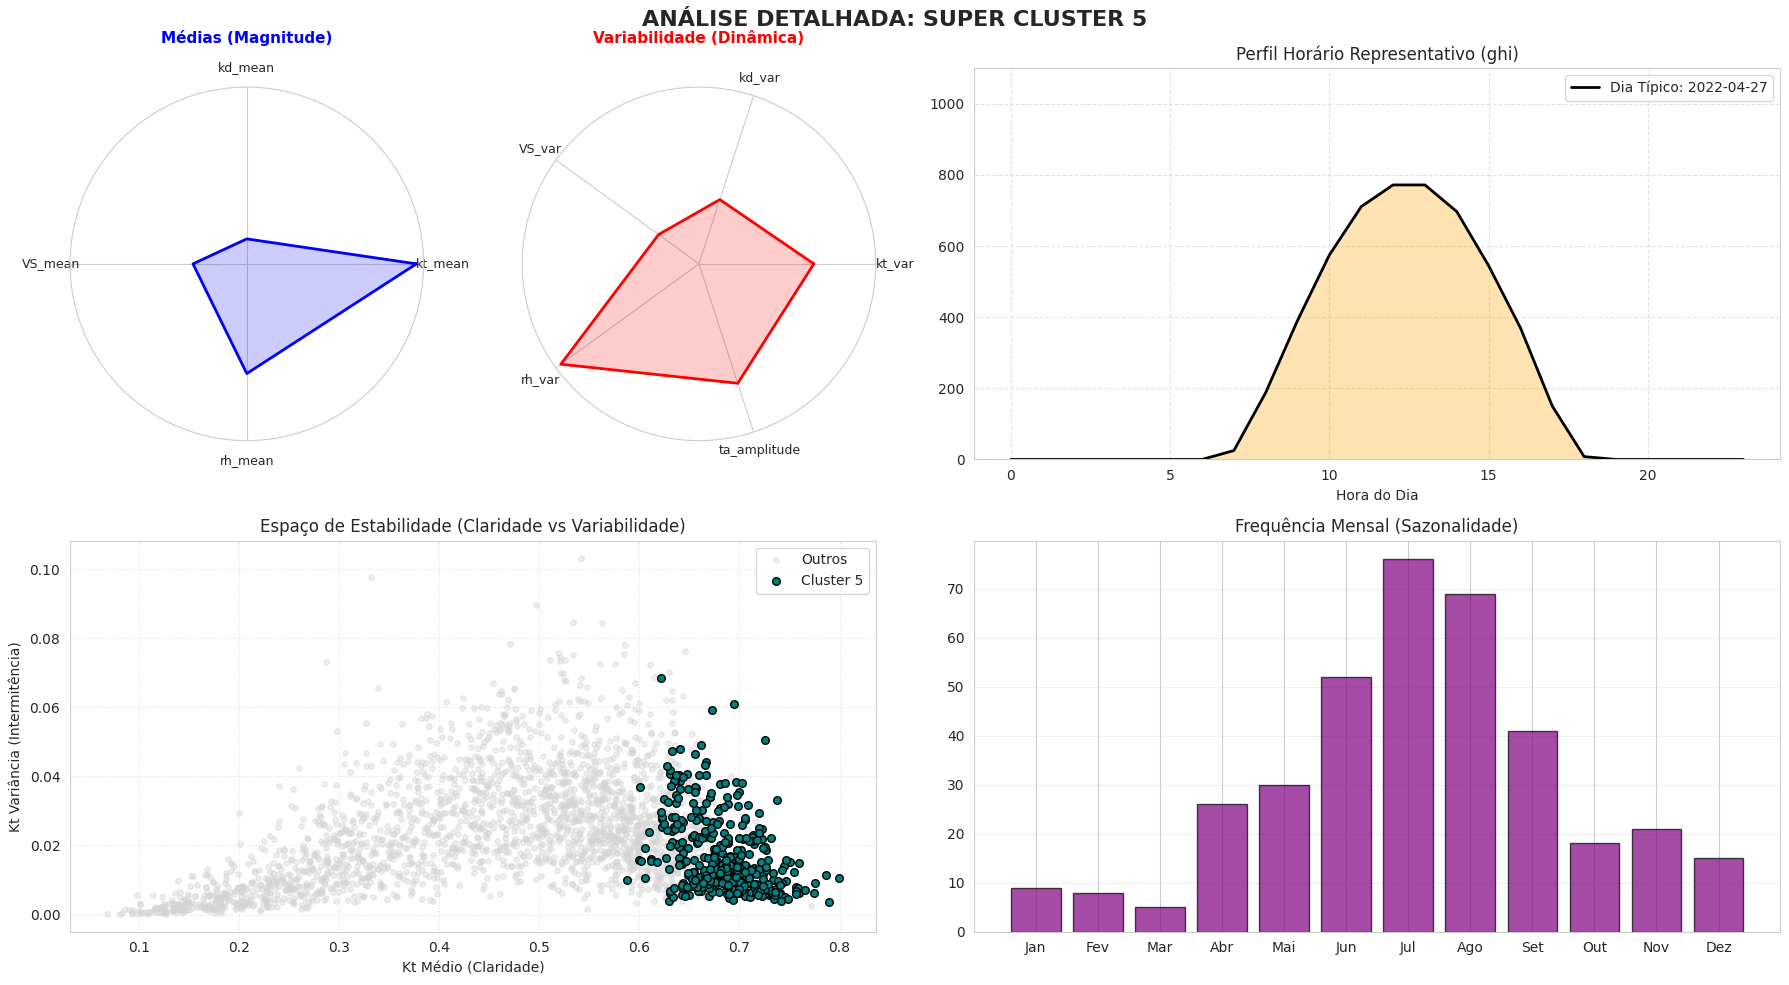

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from math import pi
from scipy.spatial import distance

def plotar_analise_cluster(df_diario, df_horario, coluna_irradiancia_horaria='GHI'):
    """
    Gera o framework de análise 'Cluster Passport' baseado no print enviado.
    
    Args:
        df_diario: Seu dataframe 'df_teste_gb' (Índice deve ser Datetime).
        df_horario: Dataframe com dados horários (deve ter índice Datetime).
        coluna_irradiancia_horaria: Nome da coluna no df_horario para plotar o perfil (ex: 'GHI', 'I_global', 'kt').
    """
    
    # 1. Definição Exata das Colunas do seu Print
    vars_medias = ['kt_mean', 'kd_mean', 'VS_mean', 'rh_mean'] #'aod_mean'
    vars_vars =   ['kt_var', 'kd_var', 'VS_var', 'rh_var', 'ta_amplitude']
    
    # Garantir que o índice é datetime
    if not isinstance(df_diario.index, pd.DatetimeIndex):
        df_diario.index = pd.to_datetime(df_diario.index)
    if not isinstance(df_horario.index, pd.DatetimeIndex):
        df_horario.index = pd.to_datetime(df_horario.index)

    # 2. Normalização (Min-Max) para o Radar Chart ficar bonito
    # (Isso não altera seus dados originais, cria uma cópia apenas para o gráfico)
    cols_to_norm = vars_medias + vars_vars
    df_norm = df_diario.copy()
    df_norm[cols_to_norm] = (df_diario[cols_to_norm] - df_diario[cols_to_norm].min()) / \
                            (df_diario[cols_to_norm].max() - df_diario[cols_to_norm].min())

    # Lista de Clusters Únicos
    clusters = sorted(df_diario['super_cluster'].unique())

    # 3. Loop para gerar um painel por Cluster
    for c in clusters:
        # Configuração do Grid (Layout)
        fig = plt.figure(figsize=(18, 10))
        gs = fig.add_gridspec(2, 4) # 2 linhas, 4 colunas
        fig.suptitle(f'ANÁLISE DETALHADA: SUPER CLUSTER {c}', fontsize=16, weight='bold', y=0.98)

        # --- A. RADAR CHART: ESTADO MÉDIO (Canto Superior Esquerdo) ---
        ax_radar1 = fig.add_subplot(gs[0, 0], polar=True)
        
        # Preparar dados do radar
        valores_med = df_norm[df_norm['super_cluster'] == c][vars_medias].mean().tolist()
        valores_med += valores_med[:1] # Fechar o ciclo
        angulos_med = [n / float(len(vars_medias)) * 2 * pi for n in range(len(vars_medias))]
        angulos_med += angulos_med[:1]
        
        ax_radar1.plot(angulos_med, valores_med, linewidth=2, linestyle='solid', color='blue')
        ax_radar1.fill(angulos_med, valores_med, 'blue', alpha=0.2)
        ax_radar1.set_xticks(angulos_med[:-1])
        ax_radar1.set_xticklabels(vars_medias, size=9)
        ax_radar1.set_title("Médias (Magnitude)", size=11, color='blue', weight='bold', y=1.1)
        ax_radar1.set_yticks([]) # Remove anéis concêntricos de valores para limpar

        # --- B. RADAR CHART: DINÂMICA/VARIÂNCIA (Canto Superior Centro-Esq) ---
        ax_radar2 = fig.add_subplot(gs[0, 1], polar=True)
        
        valores_var = df_norm[df_norm['super_cluster'] == c][vars_vars].mean().tolist()
        valores_var += valores_var[:1]
        angulos_var = [n / float(len(vars_vars)) * 2 * pi for n in range(len(vars_vars))]
        angulos_var += angulos_var[:1]
        
        ax_radar2.plot(angulos_var, valores_var, linewidth=2, linestyle='solid', color='red')
        ax_radar2.fill(angulos_var, valores_var, 'red', alpha=0.2)
        ax_radar2.set_xticks(angulos_var[:-1])
        ax_radar2.set_xticklabels(vars_vars, size=9)
        ax_radar2.set_title("Variabilidade (Dinâmica)", size=11, color='red', weight='bold', y=1.1)
        ax_radar2.set_yticks([])

        # --- C. PERFIL DIÁRIO REAL (Centróide) (Superior Direito - Ocupa 2 colunas) ---
        ax_perfil = fig.add_subplot(gs[0, 2:])
        
        # Encontrar o dia mais representativo (Centróide Euclidiano)
        sub_df = df_diario[df_diario['super_cluster'] == c]
        if not sub_df.empty:
            # Calcula o centro médio deste cluster
            centroide = sub_df[vars_medias + vars_vars].mean()
            # Acha o dia com menor distância para o centro
            distancias = sub_df[vars_medias + vars_vars].apply(lambda x: distance.euclidean(x, centroide), axis=1)
            dia_rep = distancias.idxmin() # Isso retorna o Timestamp do dia
            
            # Pega os dados horários desse dia específico
            try:
                dia_str = dia_rep.strftime('%Y-%m-%d')
                dados_dia_horario = df_horario.loc[dia_str]
                
                # Plot
                horas = dados_dia_horario.index.hour
                valores_h = dados_dia_horario[coluna_irradiancia_horaria]
                
                ax_perfil.plot(horas, valores_h, 'k-', linewidth=2, label=f'Dia Típico: {dia_str}')
                ax_perfil.fill_between(horas, valores_h, color='orange', alpha=0.3)
                ax_perfil.set_title(f"Perfil Horário Representativo ({coluna_irradiancia_horaria})")
                ax_perfil.set_xlabel("Hora do Dia")
                ax_perfil.set_ylim([0,1100])
                ax_perfil.grid(True, linestyle='--', alpha=0.5)
                ax_perfil.legend()
            except KeyError:
                ax_perfil.text(0.5, 0.5, "Dados horários não encontrados para este dia", ha='center')

        # --- D. SCATTER PLOT (Inferior Esquerdo - Ocupa 2 colunas) ---
        ax_scatter = fig.add_subplot(gs[1, 0:2])
        
        # Plot de fundo (todos os dados em cinza)
        ax_scatter.scatter(df_diario['kt_mean'], df_diario['kt_var'], c='lightgrey', alpha=0.4, s=15, label='Outros')
        # Plot do cluster (colorido)
        cluster_pts = df_diario[df_diario['super_cluster'] == c]
        ax_scatter.scatter(cluster_pts['kt_mean'], cluster_pts['kt_var'], c='teal', s=30, edgecolor='k', label=f'Cluster {c}')
        
        ax_scatter.set_xlabel('Kt Médio (Claridade)')
        ax_scatter.set_ylabel('Kt Variância (Intermitência)')
        ax_scatter.set_title("Espaço de Estabilidade (Claridade vs Variabilidade)")
        ax_scatter.legend()
        ax_scatter.grid(True, linestyle=':', alpha=0.6)

        # --- E. SAZONALIDADE (Inferior Direito - Ocupa 2 colunas) ---
        ax_hist = fig.add_subplot(gs[1, 2:])
        
        meses = cluster_pts.index.month
        ax_hist.hist(meses, bins=np.arange(1, 14)-0.5, rwidth=0.8, color='purple', alpha=0.7, edgecolor='black')
        ax_hist.set_xticks(range(1, 13))
        ax_hist.set_xticklabels(['Jan','Fev','Mar','Abr','Mai','Jun','Jul','Ago','Set','Out','Nov','Dez'])
        ax_hist.set_title("Frequência Mensal (Sazonalidade)")
        ax_hist.grid(axis='y', alpha=0.3)

        plt.tight_layout()
        plt.show()

# ==========================================
# COMO USAR COM SEUS DADOS:
# ==========================================
# df_teste_gb = pd.read_csv(...)  <-- Seu dataframe do print
# df_full_horario = pd.read_csv(...) <-- Seu dataframe com dados horários (GHI, etc)

# Basta chamar a função:
plotar_analise_cluster(df_teste_gb, df_teste, coluna_irradiancia_horaria='ghi')

In [11]:
df_teste.groupby('super_cluster')['target'].count()/24

super_cluster
0    470.000000
1    480.875000
2    439.000000
3    361.958333
4    473.000000
5    370.000000
Name: target, dtype: float64

In [12]:
df_teste.loc[df_teste.index.year == 2022].groupby('super_cluster')['target'].count()/24

super_cluster
0    62.0
1    57.0
2    67.0
3    51.0
4    65.0
5    46.0
Name: target, dtype: float64

## Split base de dados por cluster

In [13]:
dict_grupos = dict()
for i in range (0,6):
    x = df_teste[df_teste['super_cluster'] == i]
    x_list = sorted(list(set(x.loc[x.index.year != 2022].index)))
    dict_grupos.update({
        f'grupo_{i}': {
            'train': x_list[:round(len(x_list)*0.8)],
            'validation': x_list[round(len(x_list)*0.8):],
            'test': sorted(list(set(x.loc[x.index.year == 2022].index)))
            }})
    

## Treino dos Experts

In [13]:
import json
# SALVA A CONFIGURAÇÃO DE TREINAMENTO
def save_config(config, path):
    with open(os.path.join(path, 'config.json'), 'w') as f:
        json.dump(config, f, indent=4)

def save_training_log(log_data, path="outputs/training_log.csv"):
    df_log = pd.DataFrame(log_data)
    # Se o arquivo não existir, cria com cabeçalho, senão anexa
    if not os.path.exists(os.path.dirname(path)):
        os.makedirs(os.path.dirname(path))
    df_log.to_csv(path, index=False)

# SALVA A CURVA DE TREINAMENTO
def plot_learning_curve(train_losses, val_losses, save_path):
    plt.figure(figsize=(10, 6))
    plt.plot(train_losses, label='Train Loss')
    plt.plot(val_losses, label='Validation Loss')
    plt.title('Curva de Aprendizado')
    plt.xlabel('Época')
    plt.ylabel('Loss (MSE)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.savefig(save_path)
    plt.close()

In [14]:
for g in range(6):
    # 1. Instanciando os Datasets com a filtragem ativada!
    train = df_teste.loc[df_teste.index.year != 2022]

    train_dataset = SolarEfficientDatasetGroups(
        train[:round(len(train)*0.8)],     
        feature_cols=CONFIG['feature_cols'], 
        target_col=CONFIG['target_col'],
        aux_col=CONFIG['aux_col'],
        n_past=CONFIG['input_seq_len'], 
        n_future=CONFIG['output_seq_len'],
        group_col='super_cluster', 
        target_group=g
        )
    
    # 1. Instanciando os Datasets com a filtragem ativada!
    val_dataset = SolarEfficientDatasetGroups(
        train[round(len(train)*0.8):],     
        feature_cols=CONFIG['feature_cols'], 
        target_col=CONFIG['target_col'],
        aux_col=CONFIG['aux_col'],
        n_past=CONFIG['input_seq_len'], 
        n_future=CONFIG['output_seq_len'],
        group_col='super_cluster', 
        target_group=g
        )

    # 1. Setup
    #timestamp = datetime.datetime.now().strftime("%Y-%m-%d_%H-%M-%S")
    exp_name = f"{CONFIG['model_type']}_grupo_{g}"
    exp_dir = os.path.join(OUTPUT_ROOT, exp_name)
    os.makedirs(exp_dir, exist_ok=True)
    os.makedirs(ARTIFACTS_DIR, exist_ok=True)

    print(f"🚀 Iniciando: {exp_name}")
    print(f"🎯 Modo: {CONFIG['prediction_mode']} | Alvo: {CONFIG['target_col']}")
    save_config(CONFIG, exp_dir)



    train_loader = DataLoader(train_dataset, batch_size=CONFIG['batch_size'], shuffle=False)
    val_loader = DataLoader(val_dataset, batch_size=CONFIG['batch_size'], shuffle=False)

    # 6. Modelo
    model = EncDecModel(
        input_size=len(CONFIG['feature_cols']),
        hidden_sizes=CONFIG['hidden_sizes'],
        output_seq_len=CONFIG['output_seq_len'],
        output_dim=len(CONFIG['target_col']),
        cell_type=CONFIG['cell_type'],
        bidirectional=CONFIG['bidirectional'],
        use_attention=CONFIG['use_attention'],
        use_feature_attention=CONFIG['use_feature_attention'],
        dropout_prob=CONFIG['dropout']
    ).to(DEVICE)

    # modificar o criterion muda a função de erro implementado a CPILoss
    if CONFIG['loss_function'] == 'mse':
        criterion = MaskedMSELoss()
    elif CONFIG['loss_function'] == 'cpi_loss':
        criterion = CPILoss()
    elif CONFIG['loss_function'] == 'physics_loss':
        criterion = PhysicsGuidedLoss(
            lambda_hard=CONFIG['lambda_hard'], 
            lambda_soft=CONFIG['lambda_soft'],
            data_loss_type=CONFIG['physics_base_loss']
        )

    optimizer = optim.Adam(model.parameters(), lr=CONFIG['learning_rate'])
    early_stopping = EarlyStopping(patience=CONFIG['patience'], verbose=True, path=os.path.join(exp_dir, 'best_model.pt'))

    # resumo do modelo
    sample_input_size = (CONFIG['batch_size'], CONFIG['input_seq_len'], len(CONFIG['feature_cols']))

    # 7. Treino
    print("🔥 Iniciando épocas...")
    train_losses, val_losses = [], []
    start_time = time.time()

    for epoch in range(CONFIG['epochs']):
        model.train()
        epoch_metrics = {
            'epoch': epoch + 1,
            'mse_stat': 0, 
            'check_ghi':0,
            'check_dhi':0,
            'check_dni':0,
            'check_diffuse_fraction':0,
            'check_consistence':0,
            'check_overcast_condition':0,
            'check_maximum_direct_fraction':0,
            'check_tracker_off':0,
            'check_loss_physics':0,
            'total_loss':0,
        }

        val_epoch_metrics = {
            'epoch': epoch + 1,
            'mse_stat': 0, 
            'check_ghi':0,
            'check_dhi':0,
            'check_dni':0,
            'check_diffuse_fraction':0,
            'check_consistence':0,
            'check_overcast_condition':0,
            'check_maximum_direct_fraction':0,
            'check_tracker_off':0,
            'check_loss_physics':0,
            'total_loss':0,
        }
  
        #batch_losses = []
        for x, y, mask, aux, gr in train_loader:
            x, y, mask, aux, gr = x.to(DEVICE), y.to(DEVICE), mask.to(DEVICE), aux.to(DEVICE), gr.to(DEVICE)
            optimizer.zero_grad()
            out = model(x)
            active_mask = mask if CONFIG['use_mask'] else None
            if CONFIG['prediction_mode'] == 'sky':
                loss, loss_dict = criterion(out, y, aux, mask=active_mask)
                loss.backward()
                for key in loss_dict:
                    epoch_metrics[key] += loss_dict[key] / len(train_loader)

            elif CONFIG['prediction_mode'] == 'power':
                loss = criterion(out, y, mask=active_mask)
                loss.backward()

            optimizer.step()
            # Acumula as métricas para o log (média ponderada pelo tamanho do batch)
            epoch_metrics['total_loss'] += loss.item() / len(train_loader)

            #batch_losses.append(loss.item())
        
        #avg_train = np.mean(batch_losses)
        train_losses.append(epoch_metrics)

        model.eval()
        #val_batch_losses = []
        with torch.no_grad():
            for x, y, mask, aux, gr in val_loader:
                x, y, mask, aux, gr = x.to(DEVICE), y.to(DEVICE), mask.to(DEVICE), aux.to(DEVICE), gr.to(DEVICE)
                out = model(x)
                active_mask = mask if CONFIG['use_mask'] else None

                if CONFIG['prediction_mode'] == 'sky':
                    loss, loss_dict = criterion(out, y, aux, mask=active_mask)
                    # Acumula as métricas para o log (média ponderada pelo tamanho do batch)
                    for key in loss_dict:
                        val_epoch_metrics[key] += loss_dict[key] / len(val_loader)

                if CONFIG['prediction_mode'] == 'power':
                    loss = criterion(out, y, mask=active_mask)

                val_epoch_metrics['total_loss'] += loss.item() / len(val_loader)
        #avg_val = np.mean(val_batch_losses)
        val_losses.append(val_epoch_metrics)
        save_training_log(train_losses, os.path.join(exp_dir, 'log_xai.csv'))
        
        print(f"Epoch {epoch+1} | Train: {epoch_metrics['total_loss']:.6f} | Val: {val_epoch_metrics['total_loss']:.6f}")
        
        early_stopping(val_epoch_metrics['total_loss'], model)
        if early_stopping.early_stop:
            print("🛑 Early stopping.")
            break

        # 8. Logs Finais
 
    # Extrai apenas as perdas totais para gerar o gráfico
    train_total_only = [d['total_loss'] for d in train_losses]
    val_total_only = [d['total_loss'] for d in val_losses]
    plot_learning_curve(train_total_only, val_total_only, os.path.join(exp_dir, 'learning_curve.png'))
    
    """    
    pd.DataFrame({'epoch': range(1, len(train_losses)+1), 'train': train_losses, 'val': val_losses})\
        .to_csv(os.path.join(exp_dir, 'training_log.csv'), index=False)
    """

    final_metrics = {
        "best_val_loss": min(val_total_only),
        "epochs": len(train_losses),
        "time_sec": time.time() - start_time,
        "model_path": os.path.join(exp_dir, 'best_model.pt'),
    }
    with open(os.path.join(exp_dir, 'metrics.json'), 'w') as f:
        json.dump(final_metrics, f, indent=4)

    print(f"✅ Fim. Modelo salvo em: {exp_dir}")


✅ Dataset pronto. Amostras válidas (Filtrado p/ Grupo 0): 3057
✅ Dataset pronto. Amostras válidas (Filtrado p/ Grupo 0): 777
🚀 Iniciando: Teste_grupo_0
🎯 Modo: sky | Alvo: ['kt', 'fracao_difusa']
🔥 Iniciando épocas...
Epoch 1 | Train: 19.133675 | Val: 12.441938
Validation loss decreased (inf --> 12.441938).  Saving model ...
Epoch 2 | Train: 12.062941 | Val: 12.209425
Validation loss decreased (12.441938 --> 12.209425).  Saving model ...
Epoch 3 | Train: 11.243778 | Val: 11.655660
Validation loss decreased (12.209425 --> 11.655660).  Saving model ...
Epoch 4 | Train: 10.897584 | Val: 10.659661
Validation loss decreased (11.655660 --> 10.659661).  Saving model ...
Epoch 5 | Train: 10.525664 | Val: 11.258489
EarlyStopping counter: 1 out of 100
Epoch 6 | Train: 10.088382 | Val: 11.115246
EarlyStopping counter: 2 out of 100
Epoch 7 | Train: 10.160801 | Val: 11.375148
EarlyStopping counter: 3 out of 100
Epoch 8 | Train: 9.915591 | Val: 10.868984
EarlyStopping counter: 4 out of 100
Epoch 9 |

## Analise dos Resultados

In [16]:
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))
from evaluation.analysis_k_factor import KFactorAnalyzer

import json

In [17]:
EXPERIMENTS_DIRS = [
    "trained_models/Teste_2_grupo_0",
    "trained_models/Teste_2_grupo_1",
    "trained_models/Teste_2_grupo_2",
    "trained_models/Teste_2_grupo_3",
    "trained_models/Teste_2_grupo_4",
    "trained_models/Teste_2_grupo_5",   
]

OUTPUT_FILE = "analysis_outputs/Fisica_Atmosferica/"

In [ ]:
def get_config(exp_dir):
    path = os.path.join(exp_dir, 'config.json')
    if not os.path.exists(path):
        raise FileNotFoundError(f"Config não achado em {exp_dir}")
    with open(path, 'r') as f:
        return json.load(f)

def get_preprocessing_params(config):
    pp = config.get('preprocessing', {})
    return {
        'latitude': pp.get('latitude', config.get('latitude', -15.60)),
        'longitude': pp.get('longitude', config.get('longitude', -47.70)),
        'altitude': pp.get('altitude', config.get('altitude', 0)),
        'timezone': pp.get('timezone', config.get('timezone', 'Etc/GMT+3')),
        'nominal_power': pp.get('nominal_power', config.get('nominal_power', 156.0)),
        'target_col': config.get('target_col', 'target'),
        'column_mapping': pp.get('column_mapping', config.get('column_map', None)),
        'start_year': pp.get('start_year', config.get('start_year', 2018)),
        'features_to_scale': pp.get('features_to_scale', config.get('features_to_scale', []))
    }

def process_model(exp_dir, loader, grp):
    print(f"\n📂 Processando: {os.path.basename(exp_dir)}")
    
    # 1. Configurações e Preprocessor
    config = get_config(exp_dir)
    #pp_params = get_preprocessing_params(config)
    
    # 2. Carga de Dados
    # 4. Dataset (Configurado para retornar x, y, mask e aux)
    #n_past = config['input_seq_len']
    n_future = config['output_seq_len']
    
    # 5. Inicialização do Modelo (output_dim dinâmico)
    model = EncDecModel(
        input_size=len(config['feature_cols']),
        hidden_sizes=config['hidden_sizes'],
        output_seq_len=n_future,
        output_dim=len(config['target_col']), # Agora aceita multi-output
        cell_type=config.get('cell_type', 'gru'),
        bidirectional=config.get('bidirectional', False),
        use_attention=config.get('use_attention', False),
        use_feature_attention=config.get('use_feature_attention', False)
    ).to(DEVICE)
    
    # Carrega os pesos
    w_path = os.path.join(exp_dir, 'best_model.pt')
    if not os.path.exists(w_path): w_path = os.path.join(exp_dir, 'best_model.pth')
    model.load_state_dict(torch.load(w_path, map_location=DEVICE), strict=False)
    model.eval()

    # 6. Inferência Multi-Output
    print("   🔮 Gerando previsões...")
    preds_list, reals_list, aux_list = [], [], []
    
    with torch.no_grad():
        for batch_x, batch_y, batch_mask, batch_aux, batch_gp in loader:
            out = model(batch_x.to(DEVICE))
            
            # Guardamos as predições, os reais e os metadados físicos
            preds_list.append(out.cpu().numpy())
            reals_list.append(batch_y.cpu().numpy())
            aux_list.append(batch_aux.cpu().numpy())

    # Concatenamos os resultados: Shape esperado [N_amostras, Seq_Futura, Variaveis]
    y_pred_all = np.concatenate(preds_list, axis=0)
    y_true_all = np.concatenate(reals_list, axis=0)
    aux_all = np.concatenate(aux_list, axis=0)

    # Criamos o DataFrame com kt e kd (Reais e Preditos)
    # Assumindo a ordem do target_col no CONFIG: [kt, fracao_difusa]
    df_analysis = pd.DataFrame({
        'kt_real': y_true_all[:, 0, 0],
        'kd_real': y_true_all[:, 0, 1],
        'kt_pred': y_pred_all[:, 0, 0],
        'kd_pred': y_pred_all[:, 0, 1],
    })


    print(f"   ✅ DataFrame de análise gerado com {len(df_analysis)} timesteps diurnos.")


    
    return x[['kt_real', 'kd_real', 'kt_pred', 'kd_pred', 'P_fracao_difusa', 'P_kt']], os.path.basename(exp_dir), model

In [ ]:
from core.utils.xai import SolarXAIEngine

def run_analysis(exp_dir, loader, grp, save=False, process=True, df_external=None):
    try:
        # 1. Gera o DataFrame consolidado (kt, kd, real, pred, aux)
        if process == True:
            df_res, model_name, model = process_model(exp_dir, loader, grp)
        else:
            _, model_name, model = process_model(exp_dir, loader, grp)
            df_res =  df_external.copy()       
        #==================================
        #   --- Analise das Previsões ---
        #==================================
        
        # 2. INSTÂNCIA DO NOVO ANALYZER
        # Passamos o nome do modelo para criar a pasta organizada
        k_analyzer = KFactorAnalyzer(model_name=model_name, output_dir="analysis_outputs")
        
        # 3. CHAMADA DA FIGURA DE 3 PLOTS
        # Esta função vai gerar o arquivo .png com os dados de teste
        #k_analyzer.plot_kt_kd_relationship(df_res)
        k_analyzer.plot_clear_sky_day_analysis(df_res)
        k_analyzer.plot_high_variability_day_analysis(df_res)
        #k_analyzer.plot_overcast_day_analysis(df_res)
        #k_analyzer.calculate_statistical_metrics(df_res)
        k_analyzer.plot_scatter_validation(df_res)
        k_analyzer.plot_transient_day_analysis(df_res)

        #=================================
        #   --- Explainable AI (XAI) ---
        #=================================
        xai_engine = SolarXAIEngine(model, DEVICE)
        xai_dir = os.path.join("analysis_outputs", "XAI", model_name)
        os.makedirs(xai_dir, exist_ok=True)

        config = get_config(exp_dir)
        feature_names = config['feature_cols']

        # --- NÍVEL 1: Importância Global (Feature Ablation) ---
        xai_engine.compute_global_feature_importance(
            loader=loader,
            feature_names=feature_names,
            save_path=os.path.join(xai_dir, "global_feature_importance.png")
        )

        # --- NÍVEL 2: Importância Temporal (Integrated Gradients) ---
        xai_engine.compute_temporal_importance(
            dataloader=loader, 
            feature_names=feature_names,
            save_path=os.path.join(xai_dir, "temporal_importance_heatmap.png")
        )

    except Exception as e:
        print(f"   ❌ Erro: {e}")
        import traceback
        traceback.print_exc()

    if save == True:
        if df_res is not None:
            path = OUTPUT_FILE + f'{exp_dir.split('/')[1]}/tabela.csv'
            print(f"\n💾 Salvando: {path}")
            df_res.to_csv(path)
            print("✅ Tabela gerada! Confira os valores no CSV.")
            print(df_res.head())

        else:
            print("⚠️ Nenhum dado gerado.")

In [21]:
for g in range(6):

    test_dataset = SolarEfficientDatasetGroups(
        df_teste.loc[df_teste.index.year == 2022],     
        feature_cols=CONFIG['feature_cols'], 
        target_col=CONFIG['target_col'],
        aux_col=CONFIG['aux_col'],
        n_past=CONFIG['input_seq_len'], 
        n_future=CONFIG['output_seq_len'],
        group_col='super_cluster',
        target_group=g )# <-- Coluna de agrupamento do SOM

    test_loader = DataLoader(test_dataset, batch_size=CONFIG['batch_size'], shuffle=False)

    run_analysis(f"trained_models/Teste_2_grupo_{g}", test_loader, g, save=True)



✅ Dataset pronto. Amostras válidas (Filtrado p/ Grupo 0): 397
🚀 Iniciando Consolidação...

📂 Processando: Teste_2_grupo_0
   🔮 Gerando previsões...
   ✅ DataFrame de análise gerado com 397 timesteps diurnos.
   ☀️ Dia selecionado (10 amostras): 2022-10-04
   ⛈️ Dia selecionado para alta variabilidade: 2022-10-31
   📈 Gerando matriz de scatter de validação estatística...
   🌦️ Dia Transiente selecionado: 2022-10-04
      🔍 Calculando Importância Global (Ablation)...
      ⏳ Calculando Padrão Temporal (IG) para horizonte h=1...

💾 Salvando: analysis_outputs/Fisica_Atmosferica/Teste_2_grupo_0/tabela.csv
✅ Tabela gerada! Confira os valores no CSV.
                            kt_real   kd_real   kt_pred   kd_pred  \
Date_Time                                                           
2022-01-07 07:00:00-03:00  0.146216  0.938053  0.187665  0.846815   
2022-01-07 08:00:00-03:00  0.179136  0.955711  0.226158  0.847614   
2022-01-07 09:00:00-03:00  0.227197  0.955148  0.266347  0.848138   
202

## Teste Quantile Mapping

In [15]:
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))
from core.utils.quantile_mapping import SolarQuantileMapping

In [20]:
EXPERIMENTS_DIRS = [
    "trained_models/Teste_grupo_0",
    "trained_models/Teste_grupo_1",
    "trained_models/Teste_grupo_2",
    "trained_models/Teste_grupo_3",
    "trained_models/Teste_grupo_4",
    "trained_models/Teste_grupo_5", 
]

OUTPUT_FILE = "analysis_outputs/Fisica_Atmosferica/"

In [24]:
for g in range(6):

    #================================
    #   Treino do Quantile Mapping
    #================================
    test = df_teste.loc[df_teste.index.year != 2022]

    dataset = SolarEfficientDatasetGroups(
        test[0:round(len(test)*0.8)],     
        feature_cols=CONFIG['feature_cols'], 
        target_col=CONFIG['target_col'],
        aux_col=CONFIG['aux_col'],
        n_past=CONFIG['input_seq_len'], 
        n_future=CONFIG['output_seq_len'],
        group_col='super_cluster',
        target_group=g)# <-- Coluna de agrupamento do SOM

    loader = DataLoader(dataset, 
                             batch_size=CONFIG['batch_size'], shuffle=False)

    _df_res, _, _ = process_model(f"trained_models/Teste_grupo_{g}", loader, g)

    qm_kt = SolarQuantileMapping()
    qm_kd = SolarQuantileMapping()

    qm_kt.fit(obs_train=_df_res['kt_real'], mod_train=_df_res['kt_pred'])
    qm_kd.fit(obs_train=_df_res['kd_real'], mod_train=_df_res['kd_pred'])


    #
    #   Aplicação do Quantile Mapping
    #

    dataset = SolarEfficientDatasetGroups(
        df_teste.loc[df_teste.index.year == 2022],     
        feature_cols=CONFIG['feature_cols'], 
        target_col=CONFIG['target_col'],
        aux_col=CONFIG['aux_col'],
        n_past=CONFIG['input_seq_len'], 
        n_future=CONFIG['output_seq_len'],
        group_col='super_cluster',
        target_group=g)# <-- Coluna de agrupamento do SOM

    loader = DataLoader(dataset, 
                        batch_size=CONFIG['batch_size'], shuffle=False)

    df_res, model_name, model = process_model(f"trained_models/Teste_grupo_{g}", loader, g)

    # 2. Aplica a correção na base de teste de forma cega (com a máscara do seu dataset)
    #predicoes_teste_corrigidas = qm.transform(predicoes_teste_cruas, mask_teste=mascara_dia_noite_teste)
    
    df_res['kt_pred_corrigido'] = qm_kt.transform(df_res['kt_pred'])
    df_res['kd_pred_corrigido'] = qm_kd.transform(df_res['kd_pred'])

    run_analysis(f"trained_models/Teste_grupo_{g}", loader, g, save=True, process=False, df_external=df_res)

✅ Dataset pronto. Amostras válidas (Filtrado p/ Grupo 0): 3057

📂 Processando: Teste_grupo_0
   🔮 Gerando previsões...
   ✅ DataFrame de análise gerado com 3057 timesteps diurnos.
✅ Dataset pronto. Amostras válidas (Filtrado p/ Grupo 0): 566

📂 Processando: Teste_grupo_0
   🔮 Gerando previsões...
   ✅ DataFrame de análise gerado com 566 timesteps diurnos.

📂 Processando: Teste_grupo_0
   🔮 Gerando previsões...
   ✅ DataFrame de análise gerado com 566 timesteps diurnos.
   ☀️ Dia selecionado (10 amostras): 2022-11-07
   ⛈️ Dia selecionado para alta variabilidade: 2022-10-19
   📈 Gerando matriz de scatter de validação estatística...
   🌦️ Dia Transiente selecionado: 2022-12-21
      🔍 Calculando Importância Global (Ablation)...
      ⏳ Calculando Padrão Temporal (IG) para horizonte h=1...

💾 Salvando: analysis_outputs/Fisica_Atmosferica/Teste_grupo_0/tabela.csv
✅ Tabela gerada! Confira os valores no CSV.
                            kt_real   kd_real   kt_pred   kd_pred  \
Date_Time      